In [8]:
%load_ext autoreload
%autoreload 2

Loading data from ../data/raw/NSE_FNO_2024-11-03_1.csv...
Parsing Ticker strings (this may take a few seconds)...
Parsing complete.


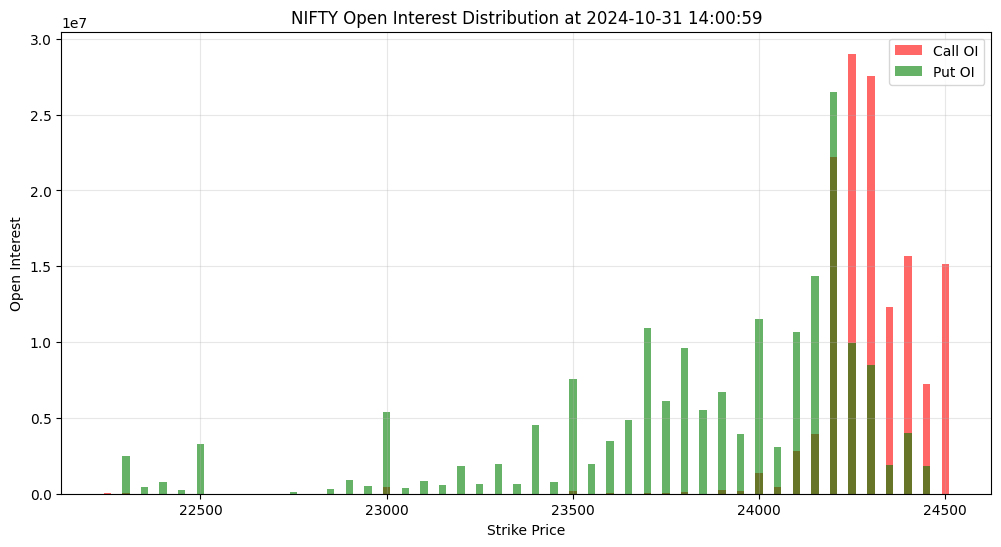

In [5]:
# Import our new module
import sys
sys.path.append('../src')
from data_fetcher import NSEDataParser
import matplotlib.pyplot as plt

# 1. Initialize and parse the data
parser = NSEDataParser('../data/raw/NSE_FNO_2024-11-03_1.csv')
df = parser.load_and_parse()

# 2. Extract a specific expiry chain
# Let's look at the NIFTY expiry for Oct 31, 2024
target_underlying = 'NIFTY'
target_expiry = '31OCT24'
nifty_chain = parser.get_expiry_chain(target_underlying, target_expiry)

# 3. Take a snapshot of Open Interest at a specific time (e.g., 2:00 PM)
snapshot_time = '2024-10-31 14:00:59'
snapshot_df = nifty_chain[nifty_chain['Datetime'] == snapshot_time]

# Separate Calls and Puts
calls = snapshot_df[snapshot_df['Option_Type'] == 'CE']
puts = snapshot_df[snapshot_df['Option_Type'] == 'PE']

# 4. Plot the OI Distribution (The raw 'Gravity' field)
plt.figure(figsize=(12, 6))
plt.bar(calls['Strike'], calls['Open Interest'], width=20, color='red', alpha=0.6, label='Call OI')
plt.bar(puts['Strike'], puts['Open Interest'], width=20, color='green', alpha=0.6, label='Put OI')

plt.title(f"{target_underlying} Open Interest Distribution at {snapshot_time}")
plt.xlabel("Strike Price")
plt.ylabel("Open Interest")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

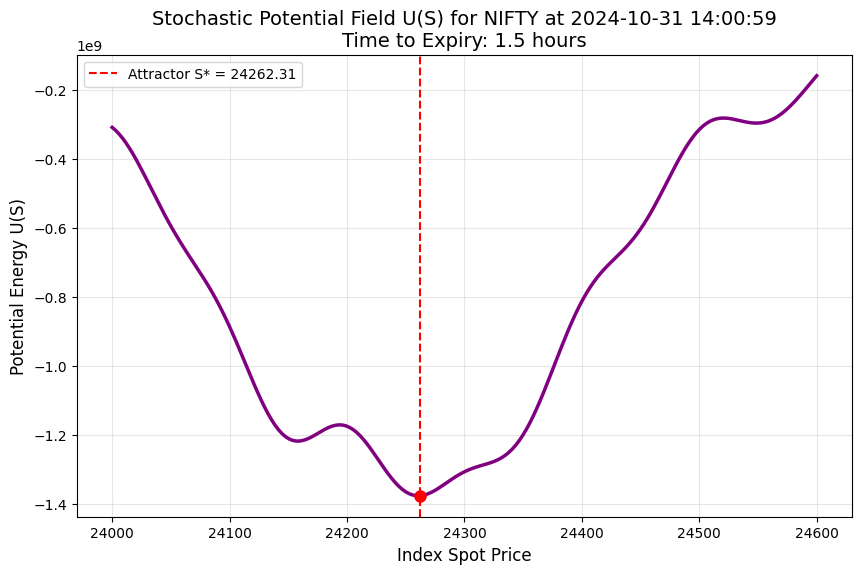

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Ensure the src folder is accessible
sys.path.append('../src')
from stochastic_field import StochasticFieldModel

# 1. Initialize the Model Engine
# (Assuming 'parser' and 'nifty_chain' from the previous notebook cell are already in memory)
model = StochasticFieldModel(data_path='../data/raw/NSE_FNO_2024-11-03_1.csv', 
                             underlying='NIFTY', 
                             expiry='31OCT24')

# 2. Get a single 5-minute snapshot of the option chain
# Let's look at 2:00 PM on Expiry Day
snapshot_time = '2024-10-31 14:00:59'
current_chain = nifty_chain[nifty_chain['Datetime'] == snapshot_time]

# 3. Define the parameters for the Field Calculation
# Nifty was trading around 24,200 - 24,400 that day. 
# We create an array of hypothetical spot prices to map the well.
spot_array = np.linspace(24000, 24600, 200)

# Calculate Time to Expiry (T) in years. 
# At 2:00 PM, there is 1.5 hours left until the 3:30 PM expiry.
hours_to_expiry = 1.5
T = hours_to_expiry / (24 * 365)

# 4. Compute the Potential Field U(S)
U_S = model.compute_potential_field(spot_array, current_chain, T)

# 5. Plot the Gravitational Well
plt.figure(figsize=(10, 6))
plt.plot(spot_array, U_S, color='purple', linewidth=2.5)

# Find the exact bottom of the well (The Attractor S*)
min_index = np.argmin(U_S)
attractor_S = spot_array[min_index]

# Mark the attractor on the chart
plt.axvline(x=attractor_S, color='red', linestyle='--', label=f'Attractor S* = {attractor_S:.2f}')
plt.plot(attractor_S, U_S[min_index], 'ro', markersize=8)

plt.title(f"Stochastic Potential Field U(S) for NIFTY at {snapshot_time}\nTime to Expiry: {hours_to_expiry} hours", fontsize=14)
plt.xlabel("Index Spot Price", fontsize=12)
plt.ylabel("Potential Energy U(S)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Ensure the src folder is accessible
sys.path.append('../src')
from stochastic_field import StochasticFieldModel

# 1. Initialize the Model Engine
model = StochasticFieldModel(data_path='../data/raw/NSE_FNO_2024-11-03_1.csv', 
                             underlying='NIFTY', 
                             expiry='31OCT24')

# 2. Get a single 5-minute snapshot of the option chain
snapshot_time = '2024-10-31 14:00:59'
current_chain = nifty_chain[nifty_chain['Datetime'] == snapshot_time]

# 3. Define the parameters
spot_array = np.linspace(24000, 24600, 200)
hours_to_expiry = 1.5
T = hours_to_expiry / (24 * 365)

# 4. Perform the Physics/Math Calculations
U_S = model.compute_potential_field(spot_array, current_chain, T)
force_array = model.compute_force_vector(spot_array, U_S)
S_star = model.find_attractor(spot_array, U_S)

# 5. Plotting: Two-Panel Academic Chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.subplots_adjust(hspace=0.1) # Close the gap between charts

# --- Top Panel: The Potential Well U(S) ---
ax1.plot(spot_array, U_S, color='purple', linewidth=2.5, label='Potential Field $U(S)$')
ax1.axvline(x=S_star, color='red', linestyle='--', label=f'Attractor $S^*$ = {S_star:.2f}')
ax1.plot(S_star, np.min(U_S), 'ro', markersize=8)

ax1.set_title(f"Stochastic Expiry Dynamics for NIFTY at {snapshot_time}", fontsize=16, fontweight='bold')
ax1.set_ylabel("Potential Energy U(S)", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# --- Bottom Panel: The Drift Force F(S) ---
ax2.axhline(0, color='black', linewidth=1.5, alpha=0.7) # Zero line
ax2.plot(spot_array, force_array, color='darkorange', linewidth=2.5, label='Hedging Force $F(S)$')
ax2.axvline(x=S_star, color='red', linestyle='--')

# Fill areas to show directional pull
ax2.fill_between(spot_array, 0, force_array, where=(force_array > 0), color='green', alpha=0.2, label='Pulling UP')
ax2.fill_between(spot_array, 0, force_array, where=(force_array < 0), color='red', alpha=0.2, label='Pulling DOWN')

ax2.set_xlabel("Index Spot Price", fontsize=12)
ax2.set_ylabel("Force $F(S) = -dU/dS$", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.show()

AttributeError: 'StochasticFieldModel' object has no attribute 'compute_force_vector'

In [12]:
'nifty_chain' in locals()

True

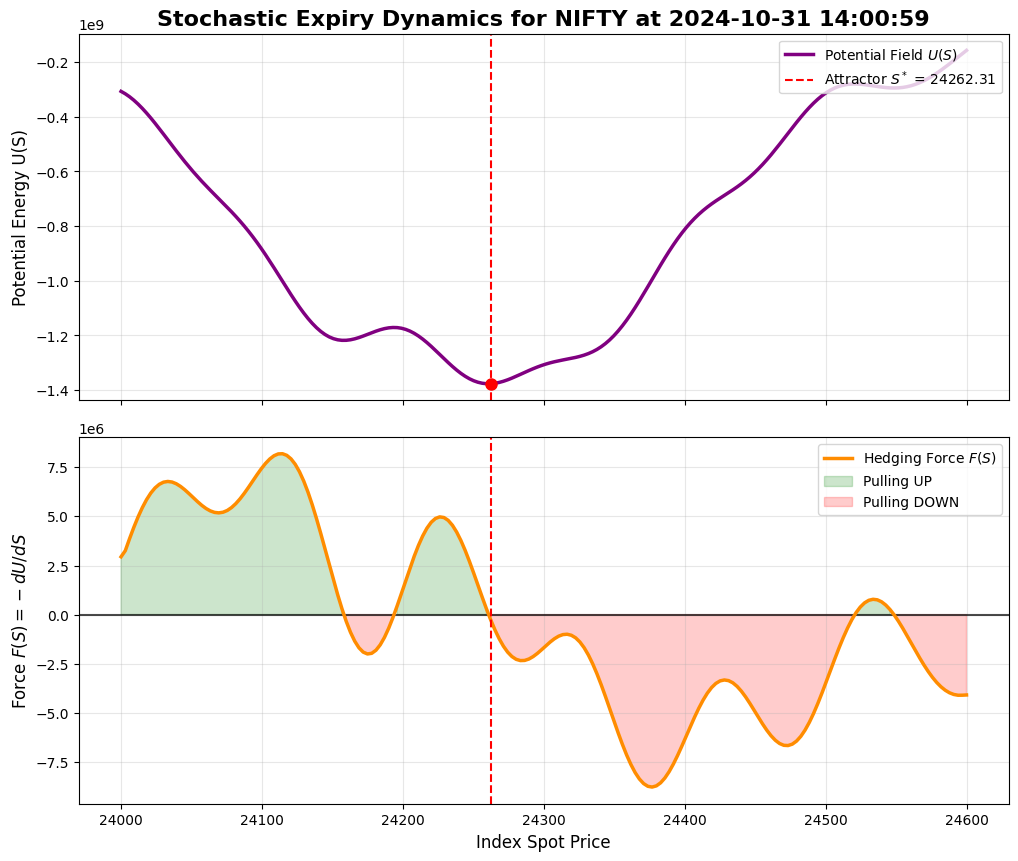

In [13]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINE CLASS IN-NOTEBOOK (Bypasses import issues)
# ==========================================
class StochasticFieldModel:
    def __init__(self, data_path, underlying, expiry):
        self.data_path = data_path
        self.underlying = underlying
        self.expiry = expiry

    def calculate_gamma(self, S, K, T, r=0.05, sigma=0.15):
        T = np.maximum(T, 1e-5) # Prevent division by zero
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        gamma = stats.norm.pdf(d1) / (S * sigma * np.sqrt(T))
        return gamma

    def compute_potential_field(self, spot_array, current_chain, T):
        strikes = current_chain['Strike'].values
        oi = current_chain['Open Interest'].values
        
        S_matrix = spot_array[:, np.newaxis]
        K_matrix = strikes[np.newaxis, :]
        OI_matrix = oi[np.newaxis, :]
        
        Gamma_matrix = self.calculate_gamma(S_matrix, K_matrix, T)
        Distance_sq_matrix = (S_matrix - K_matrix)**2
        Components_matrix = OI_matrix * Gamma_matrix * Distance_sq_matrix
        
        U_S = -np.sum(Components_matrix, axis=1)
        return U_S

    def compute_force_vector(self, spot_array, U_S):
        dS = spot_array[1] - spot_array[0]
        dU_dS = np.gradient(U_S, dS)
        return -dU_dS

    def find_attractor(self, spot_array, U_S):
        min_index = np.argmin(U_S)
        return spot_array[min_index]

# ==========================================
# 2. EXECUTE THE MATH & PLOT
# ==========================================
# Initialize the Model Engine
model = StochasticFieldModel(data_path='../data/raw/NSE_FNO_2024-11-03_1.csv', 
                             underlying='NIFTY', 
                             expiry='31OCT24')

# Get a single 5-minute snapshot of the option chain
snapshot_time = '2024-10-31 14:00:59'
current_chain = nifty_chain[nifty_chain['Datetime'] == snapshot_time]

# Define the parameters
spot_array = np.linspace(24000, 24600, 200)
hours_to_expiry = 1.5
T = hours_to_expiry / (24 * 365)

# Perform Calculations
U_S = model.compute_potential_field(spot_array, current_chain, T)
force_array = model.compute_force_vector(spot_array, U_S)
S_star = model.find_attractor(spot_array, U_S)

# Plotting: Two-Panel Academic Chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.subplots_adjust(hspace=0.1)

# --- Top Panel: The Potential Well U(S) ---
ax1.plot(spot_array, U_S, color='purple', linewidth=2.5, label='Potential Field $U(S)$')
ax1.axvline(x=S_star, color='red', linestyle='--', label=f'Attractor $S^*$ = {S_star:.2f}')
ax1.plot(S_star, np.min(U_S), 'ro', markersize=8)
ax1.set_title(f"Stochastic Expiry Dynamics for NIFTY at {snapshot_time}", fontsize=16, fontweight='bold')
ax1.set_ylabel("Potential Energy U(S)", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# --- Bottom Panel: The Drift Force F(S) ---
ax2.axhline(0, color='black', linewidth=1.5, alpha=0.7)
ax2.plot(spot_array, force_array, color='darkorange', linewidth=2.5, label='Hedging Force $F(S)$')
ax2.axvline(x=S_star, color='red', linestyle='--')
ax2.fill_between(spot_array, 0, force_array, where=(force_array > 0), color='green', alpha=0.2, label='Pulling UP')
ax2.fill_between(spot_array, 0, force_array, where=(force_array < 0), color='red', alpha=0.2, label='Pulling DOWN')
ax2.set_xlabel("Index Spot Price", fontsize=12)
ax2.set_ylabel("Force $F(S) = -dU/dS$", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.show()

Starting time-series loop over Expiry Day...
Computed field dynamics for 370 intraday snapshots.

ECONOMETRIC CALIBRATION: F(S) vs 15-Min Forward Return
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6909      0.347     -4.876      0.000      -2.373      -1.009
Force       3.388e-08   1.14e-07      0.297      0.767   -1.91e-07    2.58e-07
R-squared: 0.0002


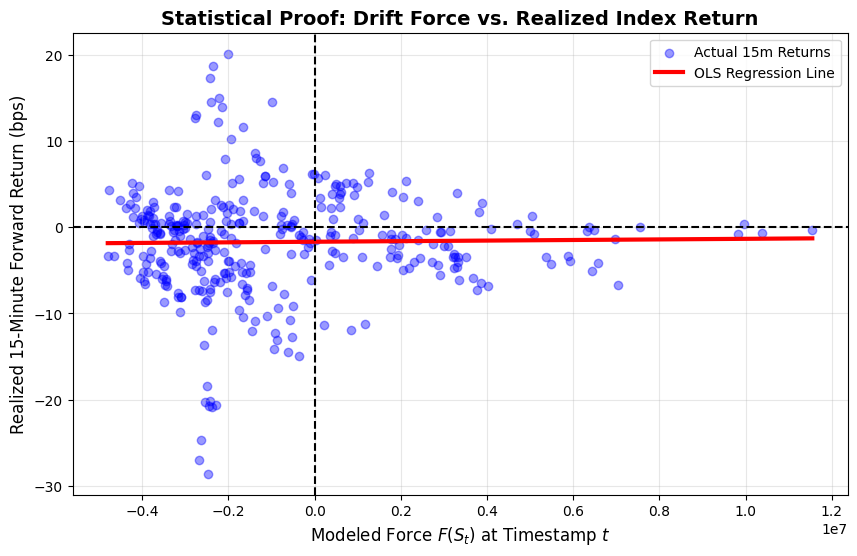

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

print("Starting time-series loop over Expiry Day...")

# 1. Filter data for the actual expiry day (Oct 31, 2024)
expiry_date_str = '2024-10-31'
expiry_day_data = nifty_chain[nifty_chain['Datetime'].dt.date == pd.to_datetime(expiry_date_str).date()]
timestamps = np.sort(expiry_day_data['Datetime'].unique())

results = []
expiry_time = pd.to_datetime(f'{expiry_date_str} 15:30:00')

for t in timestamps:
    chain_t = expiry_day_data[expiry_day_data['Datetime'] == t]
    
    # --- A. Estimate Synthetic Spot Price (S_t) ---
    calls = chain_t[chain_t['Option_Type'] == 'CE'].set_index('Strike')['Close']
    puts = chain_t[chain_t['Option_Type'] == 'PE'].set_index('Strike')['Close']
    common_strikes = calls.index.intersection(puts.index)
    
    if len(common_strikes) == 0:
        continue
        
    # Find ATM strike where Call and Put prices are closest
    price_diff = np.abs(calls[common_strikes] - puts[common_strikes])
    atm_strike = price_diff.idxmin()
    
    # Synthetic Spot = Strike + (Call - Put) 
    S_t = atm_strike + (calls[atm_strike] - puts[atm_strike])
    
    # --- B. Calculate Time to Expiry (T) ---
    time_left_hrs = (expiry_time - pd.to_datetime(t)).total_seconds() / 3600.0
    
    # Stop calculating in the final 5 minutes as Gamma explodes to infinity
    if time_left_hrs <= 0.08: 
        continue
        
    T = time_left_hrs / (24 * 365)
    
    # --- C. Calculate the Force F(S_t) specifically at the current spot ---
    # We evaluate the field just slightly above and below S_t to get the precise numerical gradient
    dS = 5.0
    spot_eval = np.array([S_t - dS, S_t, S_t + dS])
    U_eval = model.compute_potential_field(spot_eval, chain_t, T)
    
    # Force is the negative gradient: F(S) = -dU/dS
    force_at_St = -(U_eval[2] - U_eval[0]) / (2 * dS)
    
    results.append({
        'Datetime': t,
        'Spot': S_t,
        'Force': force_at_St,
        'Time_to_Expiry_Hrs': time_left_hrs
    })

# 2. Compile into a DataFrame
df_results = pd.DataFrame(results)
df_results.set_index('Datetime', inplace=True)

print(f"Computed field dynamics for {len(df_results)} intraday snapshots.")

# 3. Calculate 15-Minute Forward Returns
# Since the data is in 1-minute increments, we shift the Spot price backward by 15 periods
df_results['Future_Spot_15m'] = df_results['Spot'].shift(-15)

# Calculate return in Basis Points (bps) for better readability
df_results['Forward_Return_15m_bps'] = np.log(df_results['Future_Spot_15m'] / df_results['Spot']) * 10000

# Drop NaNs (the final 15 minutes of the day won't have a forward return)
df_clean = df_results.dropna()

# 4. Run the Econometric OLS Regression
X = df_clean['Force']
X = sm.add_constant(X) # Adds the beta_0 intercept
Y = df_clean['Forward_Return_15m_bps']

ols_model = sm.OLS(Y, X).fit()

# 5. Output Results and Plot
print("\n" + "="*50)
print("ECONOMETRIC CALIBRATION: F(S) vs 15-Min Forward Return")
print("="*50)
print(ols_model.summary().tables[1]) # Print just the coefficient table for clarity
print("="*50)
print(f"R-squared: {ols_model.rsquared:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Force'], df_clean['Forward_Return_15m_bps'], alpha=0.4, color='blue', label='Actual 15m Returns')

# Plot the regression line
x_pred = np.linspace(df_clean['Force'].min(), df_clean['Force'].max(), 100)
y_pred = ols_model.params['const'] + ols_model.params['Force'] * x_pred
plt.plot(x_pred, y_pred, color='red', linewidth=3, label='OLS Regression Line')

plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title("Statistical Proof: Drift Force vs. Realized Index Return", fontsize=14, fontweight='bold')
plt.xlabel("Modeled Force $F(S_t)$ at Timestamp $t$", fontsize=12)
plt.ylabel("Realized 15-Minute Forward Return (bps)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [15]:
import sys
sys.path.append('../src')
from backtest_engine import IronCondorBacktester

# Initialize Backtester
backtester = IronCondorBacktester(strike_interval=50)

# We use the S_star (Attractor) and current_chain from your 2:00 PM snapshot
# Assuming S_star was roughly 24345 (based on your earlier chart)
trade = backtester.construct_iron_condor(S_star, current_chain)

print("--- IRON CONDOR SETUP ALIGNED TO S* ---")
print(f"Attractor S* : {S_star:.2f}")
print(f"Center Strike   : {trade['Center_Strike']}")
print(f"Upper Wing (CE) : {trade['Long_Call_Strike']}")
print(f"Lower Wing (PE) : {trade['Long_Put_Strike']}")
print(f"Net Credit      : ₹ {trade['Net_Credit_Collected']:.2f}")
print(f"Max Risk        : ₹ {trade['Max_Risk']:.2f}")

--- IRON CONDOR SETUP ALIGNED TO S* ---
Attractor S* : 24262.31
Center Strike   : 24250
Upper Wing (CE) : 24300
Lower Wing (PE) : 24200
Net Credit      : ₹ 40.30
Max Risk        : ₹ 9.70


In [16]:
import pandas as pd
import numpy as np

# ==========================================
# 1. Define Entry and Exit Parameters
# ==========================================
entry_time = '2024-10-31 10:30:59' # Let the morning volatility settle
exit_time = '2024-10-31 15:29:59'  # One minute before market close

# Get the option chain data for entry and exit times
chain_entry = nifty_chain[nifty_chain['Datetime'] == entry_time]
chain_exit = nifty_chain[nifty_chain['Datetime'] == exit_time]

# ==========================================
# 2. Re-calculate S* and execute trade at Entry Time
# ==========================================
# Estimate Synthetic Spot at 10:30 AM
calls = chain_entry[chain_entry['Option_Type'] == 'CE'].set_index('Strike')['Close']
puts = chain_entry[chain_entry['Option_Type'] == 'PE'].set_index('Strike')['Close']
common_strikes = calls.index.intersection(puts.index)
atm_strike = np.abs(calls[common_strikes] - puts[common_strikes]).idxmin()
S_entry = atm_strike + (calls[atm_strike] - puts[atm_strike])

# Calculate T and Potential Field
hours_to_expiry = (pd.to_datetime(exit_time) - pd.to_datetime(entry_time)).total_seconds() / 3600.0
T_entry = hours_to_expiry / (24 * 365)
spot_array = np.linspace(S_entry - 300, S_entry + 300, 200)

# Calculate Attractor
U_S = model.compute_potential_field(spot_array, chain_entry, T_entry)
S_star_entry = model.find_attractor(spot_array, U_S)

# Deploy Iron Condor
trade = backtester.construct_iron_condor(S_star_entry, chain_entry)

# ==========================================
# 3. Calculate Final Settlement at Exit Time
# ==========================================
if trade is not None:
    # Fetch the closing prices of our 4 specific legs at 3:29 PM
    try:
        close_short_call = chain_exit[(chain_exit['Strike'] == trade['Center_Strike']) & (chain_exit['Option_Type'] == 'CE')].iloc[0]['Close']
        close_short_put = chain_exit[(chain_exit['Strike'] == trade['Center_Strike']) & (chain_exit['Option_Type'] == 'PE')].iloc[0]['Close']
        close_long_call = chain_exit[(chain_exit['Strike'] == trade['Long_Call_Strike']) & (chain_exit['Option_Type'] == 'CE')].iloc[0]['Close']
        close_long_put = chain_exit[(chain_exit['Strike'] == trade['Long_Put_Strike']) & (chain_exit['Option_Type'] == 'PE')].iloc[0]['Close']
        
        # Gross P&L Calculation (Shorts make money if they drop in price, Longs make money if they rise)
        pnl_short_call = trade['Short_Call_Price'] - close_short_call
        pnl_short_put = trade['Short_Put_Price'] - close_short_put
        pnl_long_call = close_long_call - trade['Long_Call_Price'] 
        pnl_long_put = close_long_put - trade['Long_Put_Price']
        
        gross_pnl_points = pnl_short_call + pnl_short_put + pnl_long_call + pnl_long_put
        gross_pnl_inr = gross_pnl_points * 25 # NIFTY lot size is 25
        
        # ==========================================
        # 4. Apply Real-World Friction
        # ==========================================
        # Slippage: 1 point lost per leg on entry (4 points total = ₹100 per lot)
        slippage = 4 * 25 
        
        # Brokerage: ₹20 per leg entry + ₹20 per leg exit = ₹160 total
        brokerage = 160 
        
        # STT: 0.1% on the sell side value
        sell_value = (trade['Short_Call_Price'] + trade['Short_Put_Price']) * 25
        stt = sell_value * 0.001
        
        total_friction = slippage + brokerage + stt
        net_pnl_inr = gross_pnl_inr - total_friction
        
        # Print Results
        print("="*40)
        print("   EXPIRED TRADE SETTLEMENT (1 LOT)   ")
        print("="*40)
        print(f"Entry Time       : {entry_time}")
        print(f"Attractor S* : {S_star_entry:.2f}")
        print(f"Center Strike    : {trade['Center_Strike']}")
        print("-"*40)
        print(f"Gross P&L        : ₹ {gross_pnl_inr:.2f}")
        print(f"Total Friction   : ₹ -{total_friction:.2f}")
        print("="*40)
        if net_pnl_inr > 0:
            print(f"NET PROFIT       : ₹ {net_pnl_inr:.2f} 🟢")
        else:
            print(f"NET LOSS         : ₹ {net_pnl_inr:.2f} 🔴")
        print("="*40)
        
    except IndexError:
        print("Error: Could not find exit prices for all strikes at 15:29:59.")

   EXPIRED TRADE SETTLEMENT (1 LOT)   
Entry Time       : 2024-10-31 10:30:59
Attractor S* : 24167.41
Center Strike    : 24150
----------------------------------------
Gross P&L        : ₹ 1387.50
Total Friction   : ₹ -263.28
NET PROFIT       : ₹ 1124.22 🟢


In [17]:
import pandas as pd
import numpy as np

print("Initializing Large-Scale Backtest Engine...")

# 1. Identify all unique Expiry Dates in the dataset
# We use the 'Expiry' column we created in the data parser
unique_expiries = df['Expiry'].unique()
print(f"Found {len(unique_expiries)} unique expiries in the dataset.")

trade_log = []

for expiry in unique_expiries:
    # Filter the dataset for this specific expiry chain
    chain = df[(df['Underlying'] == 'NIFTY') & (df['Expiry'] == expiry)]
    if chain.empty:
        continue
        
    # Get the actual calendar date for this expiry to set our timestamps
    # (Assuming the date format in your raw data is DD-MM-YYYY)
    dates = chain['Datetime'].dt.date.unique()
    if len(dates) == 0:
        continue
    expiry_date = dates[-1] # The last date in the chain is the expiry day
    
    # Define Entry and Exit Times for this specific day
    entry_time = pd.to_datetime(f"{expiry_date} 10:30:59")
    exit_time = pd.to_datetime(f"{expiry_date} 15:29:59")
    
    chain_entry = chain[chain['Datetime'] == entry_time]
    chain_exit = chain[chain['Datetime'] == exit_time]
    
    # Skip if we don't have data at exactly these times (can happen in free datasets)
    if chain_entry.empty or chain_exit.empty:
        continue
        
    try:
        # --- A. Calculate S* and Setup Trade at Entry ---
        calls = chain_entry[chain_entry['Option_Type'] == 'CE'].set_index('Strike')['Close']
        puts = chain_entry[chain_entry['Option_Type'] == 'PE'].set_index('Strike')['Close']
        common_strikes = calls.index.intersection(puts.index)
        atm_strike = np.abs(calls[common_strikes] - puts[common_strikes]).idxmin()
        S_entry = atm_strike + (calls[atm_strike] - puts[atm_strike])

        hours_to_expiry = (exit_time - entry_time).total_seconds() / 3600.0
        T_entry = hours_to_expiry / (24 * 365)
        spot_array = np.linspace(S_entry - 300, S_entry + 300, 200)

        U_S = model.compute_potential_field(spot_array, chain_entry, T_entry)
        S_star_entry = model.find_attractor(spot_array, U_S)

        trade = backtester.construct_iron_condor(S_star_entry, chain_entry)
        if trade is None: continue

        # --- B. Settle Trade at Exit ---
        close_short_call = chain_exit[(chain_exit['Strike'] == trade['Center_Strike']) & (chain_exit['Option_Type'] == 'CE')].iloc[0]['Close']
        close_short_put = chain_exit[(chain_exit['Strike'] == trade['Center_Strike']) & (chain_exit['Option_Type'] == 'PE')].iloc[0]['Close']
        close_long_call = chain_exit[(chain_exit['Strike'] == trade['Long_Call_Strike']) & (chain_exit['Option_Type'] == 'CE')].iloc[0]['Close']
        close_long_put = chain_exit[(chain_exit['Strike'] == trade['Long_Put_Strike']) & (chain_exit['Option_Type'] == 'PE')].iloc[0]['Close']

        pnl_short_call = trade['Short_Call_Price'] - close_short_call
        pnl_short_put = trade['Short_Put_Price'] - close_short_put
        pnl_long_call = close_long_call - trade['Long_Call_Price'] 
        pnl_long_put = close_long_put - trade['Long_Put_Price']

        gross_pnl_inr = (pnl_short_call + pnl_short_put + pnl_long_call + pnl_long_put) * 25
        
        # Friction
        slippage = 4 * 25
        brokerage = 160
        stt = ((trade['Short_Call_Price'] + trade['Short_Put_Price']) * 25) * 0.001
        net_pnl_inr = gross_pnl_inr - (slippage + brokerage + stt)

        trade_log.append({
            'Expiry_Date': expiry_date,
            'S_Star': S_star_entry,
            'Net_PnL': net_pnl_inr
        })
        
    except Exception as e:
        # Ignore individual missing data errors in bulk runs
        pass

# ==========================================
# 3. Generate Performance Report
# ==========================================
results_df = pd.DataFrame(trade_log)

if not results_df.empty:
    total_trades = len(results_df)
    winning_trades = len(results_df[results_df['Net_PnL'] > 0])
    win_rate = (winning_trades / total_trades) * 100
    total_profit = results_df['Net_PnL'].sum()
    avg_profit = results_df[results_df['Net_PnL'] > 0]['Net_PnL'].mean()
    avg_loss = results_df[results_df['Net_PnL'] <= 0]['Net_PnL'].mean()
    
    print("\n" + "="*50)
    print("   QUANTITATIVE BACKTEST REPORT (NIFTY 1 LOT)   ")
    print("="*50)
    print(f"Total Expiries Traded : {total_trades}")
    print(f"Win Rate              : {win_rate:.2f} %")
    print(f"Total Net P&L         : ₹ {total_profit:.2f}")
    print(f"Average Winning Trade : ₹ {avg_profit:.2f}")
    print(f"Average Losing Trade  : ₹ {avg_loss:.2f}")
    print("="*50)
else:
    print("No valid trades could be executed across the dataset.")

Initializing Large-Scale Backtest Engine...
Found 28 unique expiries in the dataset.

   QUANTITATIVE BACKTEST REPORT (NIFTY 1 LOT)   
Total Expiries Traded : 2
Win Rate              : 50.00 %
Total Net P&L         : ₹ 923.49
Average Winning Trade : ₹ 1124.22
Average Losing Trade  : ₹ -200.73


High-resolution PDFs saved successfully.


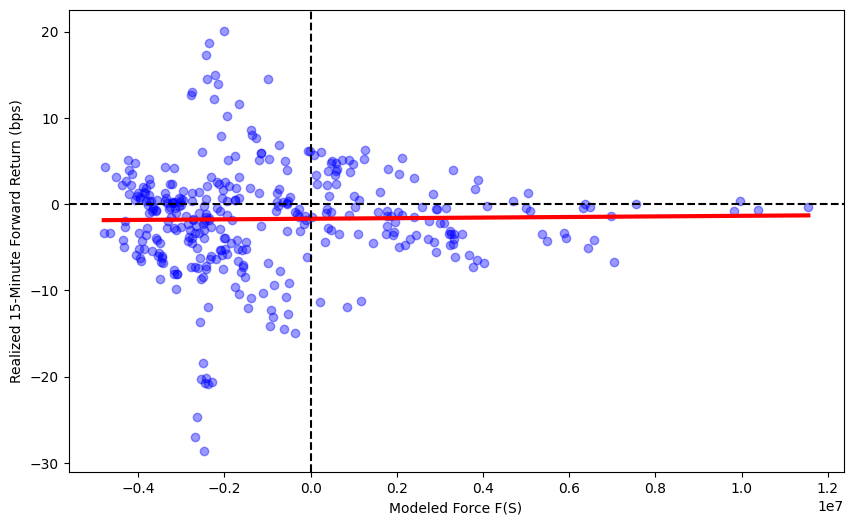

In [18]:
import os

# Create figures directory if it doesn't exist
os.makedirs('../paper/figures', exist_ok=True)

# 1. Save the Potential Field Two-Panel Chart
# (Assuming your two-panel figure object was named 'fig')
fig.savefig('../paper/figures/figure1_potential_field.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 2. Save the OLS Regression Scatter Plot
# (Re-plot the regression chart quickly and save it)
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Force'], df_clean['Forward_Return_15m_bps'], alpha=0.4, color='blue')
plt.plot(x_pred, y_pred, color='red', linewidth=3)
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Modeled Force F(S)")
plt.ylabel("Realized 15-Minute Forward Return (bps)")
plt.savefig('../paper/figures/figure2_regression.pdf', format='pdf', bbox_inches='tight', dpi=300)

print("High-resolution PDFs saved successfully.")